In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.sparse import hstack
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import hstack
from sklearn.metrics.pairwise import cosine_similarity
from src.paths import DATA_PROCESSED

Je crée une matrice combinant genres, cast et tags, pondérés différemment (1.0 / 0.4 / 0.2)

In [2]:
with open(DATA_PROCESSED / "data_reco.pkl", 'rb') as f:
    d = pickle.load(f)


cast_final_Q92 = d['cast_final_Q92']
genre_cols     = d['genre_cols']
matrice = hstack([d['genre_matrice'] * 1,
                  d['cast_matrice']  * 0.4,
                  d['tags_matrice']  * 0.2]).tocsr()



Je vais utiliser SVD pour qu'il compresse la matrice sur 300 colonnes pour tester, et normalize derriere 

In [3]:
svd = TruncatedSVD(n_components=300, random_state=42)
X_svd = svd.fit_transform(matrice)
X_svd = normalize(X_svd)



In [4]:
X_svd.shape

(26463, 300)

On a bien une matrice de 26463 x 300
Voyons la variance sur un plot 

21 0.8001084161367803


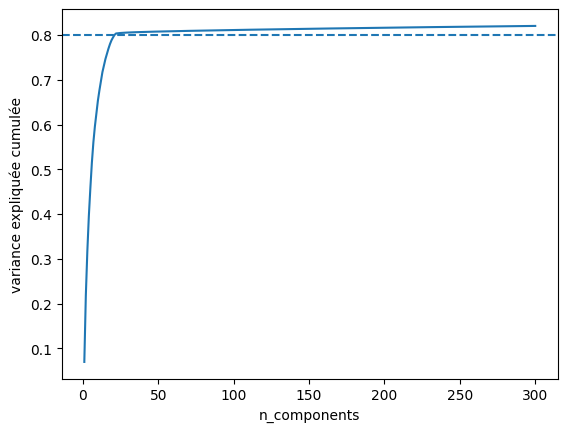

In [5]:
Variance = svd.explained_variance_ratio_.cumsum()
plt.plot(range(1, 301), Variance)
plt.axhline(0.8, ls='--')
plt.xlabel("n_components")
plt.ylabel("variance expliquée cumulée")
k = (Variance < 0.8).sum() +1
print(k, Variance[k-1])

21 composantes suffisent pour 80 % de la variance, mais le test de recommandation montre que cette variance ne porte pas l'information utile.
En 21 dimensions toutes les similarités s'écrasent à 1,0

In [6]:
SVD_21 = TruncatedSVD(n_components=21, random_state=42)
X_svd_21 = SVD_21.fit_transform(matrice)
X_svd_21 = normalize(X_svd_21)
X_svd_21.shape

(26463, 21)

In [7]:
def get_position(titre):
    match = cast_final_Q92[cast_final_Q92['primaryTitle'].str.contains(titre, case=False, na=False)]
    return match.index[0]

In [24]:

position = get_position('matrix')
pos_reelle = cast_final_Q92.index.get_loc(position)
sim = cosine_similarity(X_svd_21[[pos_reelle]], X_svd_21).flatten()
sim.shape
df_temp = cast_final_Q92.copy()
df_temp['sim'] = sim
df_temp = df_temp.sort_values('sim', ascending=False)
df_temp[['primaryTitle', 'sim', 'weight_rating']].head(10)


,primaryTitle,sim,weight_rating
8137,The Matrix,1.000000,8.692991
9080,The Matrix Revolutions,1.000000,6.694208
9004,The Matrix Reloaded,1.000000,7.190439
10603,Ultraviolet,1.000000,4.517394
11787,X-Men Origins: Wolverine,0.999999,6.496294
5308,Alien Nation,0.999999,6.262929
3770,The Black Hole,0.999999,5.943680
4853,Trancers,0.999999,6.064258
14837,Iron Man 2,0.999999,6.895111
2960,Conquest of the Planet of the Apes,0.999999,6.107555
